In [1]:
# title and stuff

In [33]:
# import packages
from datetime import datetime
import plot_functions
import importlib
importlib.reload(plot_functions)

import copy
import glob
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

import os
import pandas as pd


In [2]:
#AREA_NAME = "Flagstaff_V0_to_V4"
AREA_NAME = "Happy_Sad_Boulders"
#AREA_NAME = "Buttermilks"

In [3]:
dfs = plot_functions.find_area_csvs(area_name = AREA_NAME, data_dir='data')

Loaded 'csv_df' from data/20260410_122014_Happy_Sad_Boulders_csv_df.csv  (785 rows)
Loaded 'unique_user_df' from data/20260410_155603_Happy_Sad_Boulders_unique_user_df.csv  (5405 rows)
Loaded 'area_df_with_stats' from data/20260410_132909_Happy_Sad_Boulders_area_df_with_stats.csv  (43970 rows)
Loaded 'user_info_df' from data/20260410_222232_Happy_Sad_Boulders_user_info_df.csv  (5405 rows)
Loaded 'area_df_with_user_info' from data/20260410_222241_Happy_Sad_Boulders_area_df_with_user_info.csv  (43970 rows)


In [4]:
dfs.keys()

dict_keys(['csv_df', 'unique_user_df', 'area_df_with_stats', 'user_info_df', 'area_df_with_user_info'])

In [5]:
area_df = dfs['area_df_with_user_info']
#user_info_df

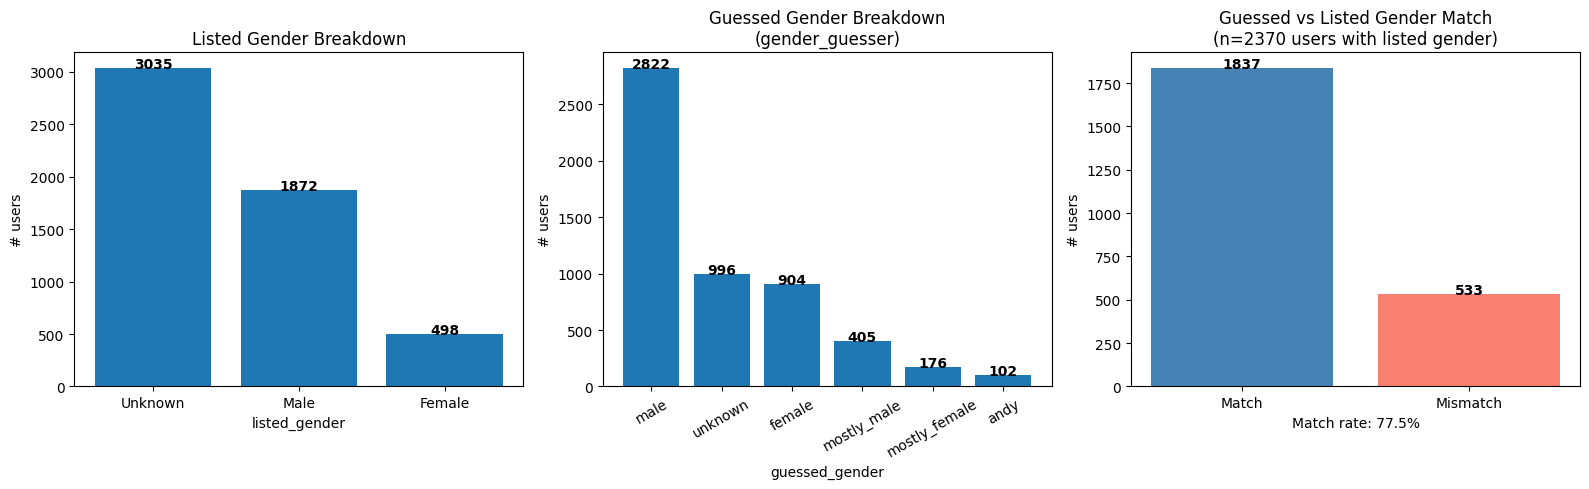

In [6]:
plot_functions.plot_gender_breakdown(user_info_df = dfs['user_info_df'])

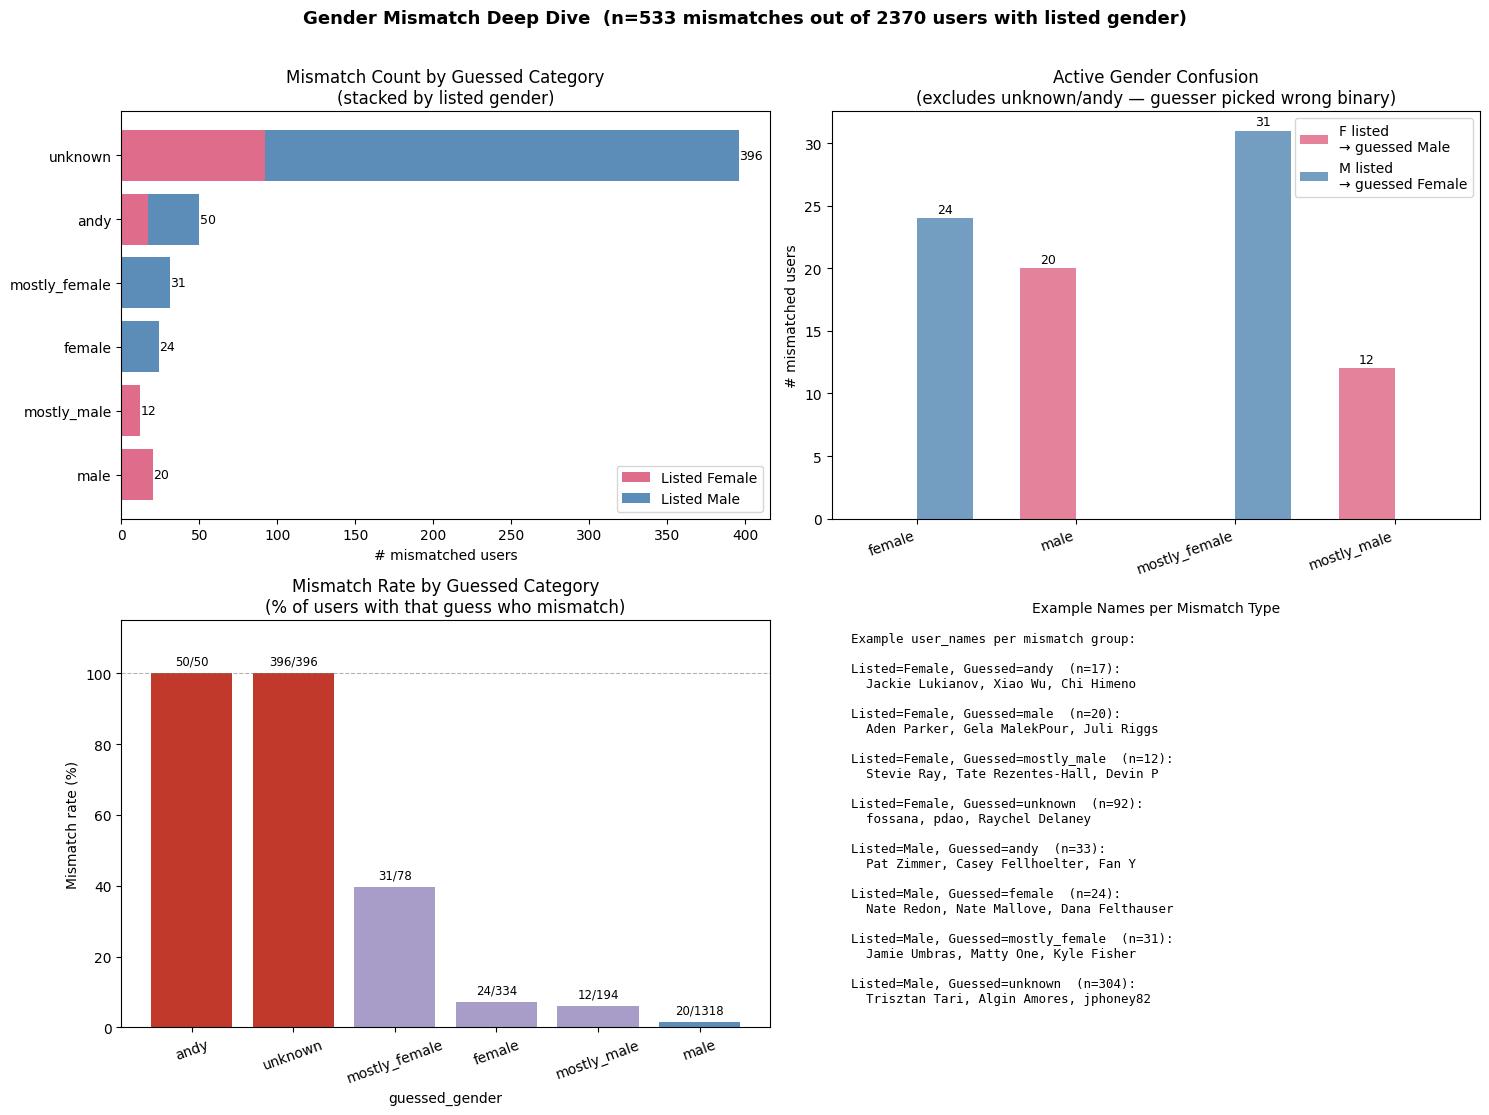

In [7]:
plot_functions.plot_gender_mismatch_detail(user_info_df = dfs['user_info_df'])

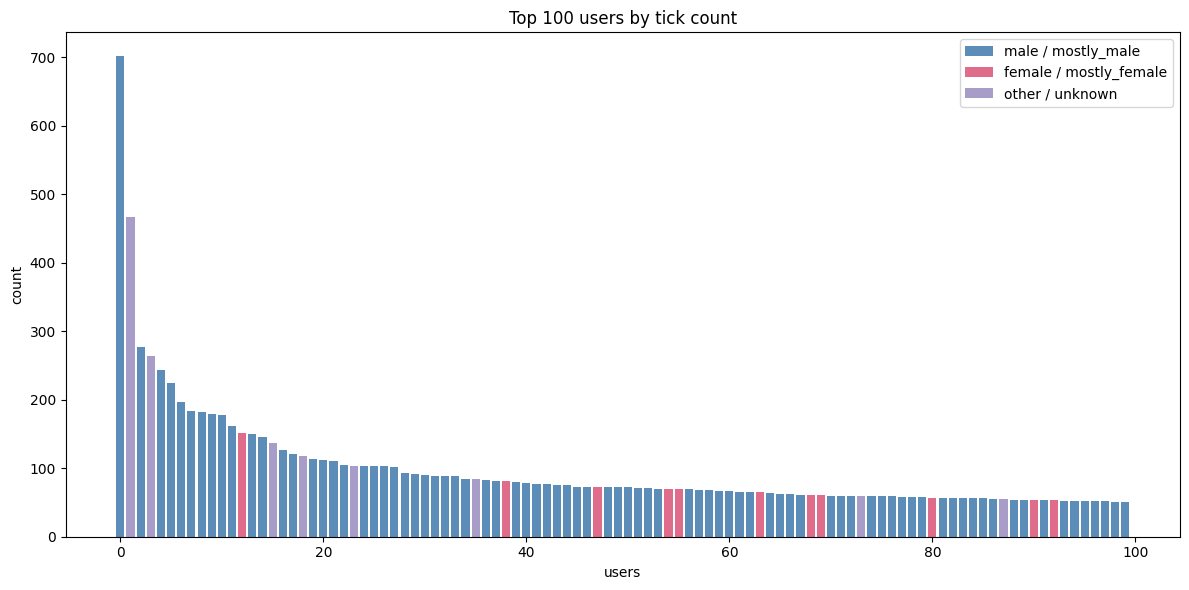

Total unique users: 5277
user.name
Euan Cameron               701
MP Testing Test            467
Jason Akua Makana Petty    277
Anonymous                  264
Riley K                    244
Troy Fauteux               224
Andy L                     196
Trisztan Tari              183
Marty Lewis                182
Brad Fauteux               179
Name: count, dtype: int64


In [8]:
plot_functions.plot_top_users_by_ticks(area_df = dfs['area_df_with_user_info'], top_n = 100)

In [29]:
area_df['V-grade'].value_counts()

V-grade
V1        5246
V4        4986
V3        4955
V2        4364
V0        4262
V5        3940
V0+       3641
V6        2941
V0-       2725
V7        1305
V9         527
V3-        465
V2+        425
V8         416
V3+        352
V10        316
V1+        291
V7-8       280
V7+        263
V4-5       177
V5+        147
V5-6       118
V0-1        75
V11         66
V9+         63
V6+         56
V3-4        53
V1-         50
V8-         39
V11-        27
V2-3        23
V1-2        19
V9-         18
V6-         17
V4+         17
V7-         15
V12         12
V10-        10
V8-9        10
V10-11       9
V14          5
V11-12       4
V6-7         4
V13          1
V4-          1
Name: count, dtype: int64

/home/cbond/climb_data_code/plot_functions.py:385: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  plot_df = plot_df[plot_df['V-grade'].astype(str).str.contains(pattern, regex=True)]


17 routes meet the minimum rating threshold (>=5 female, >=5 male)


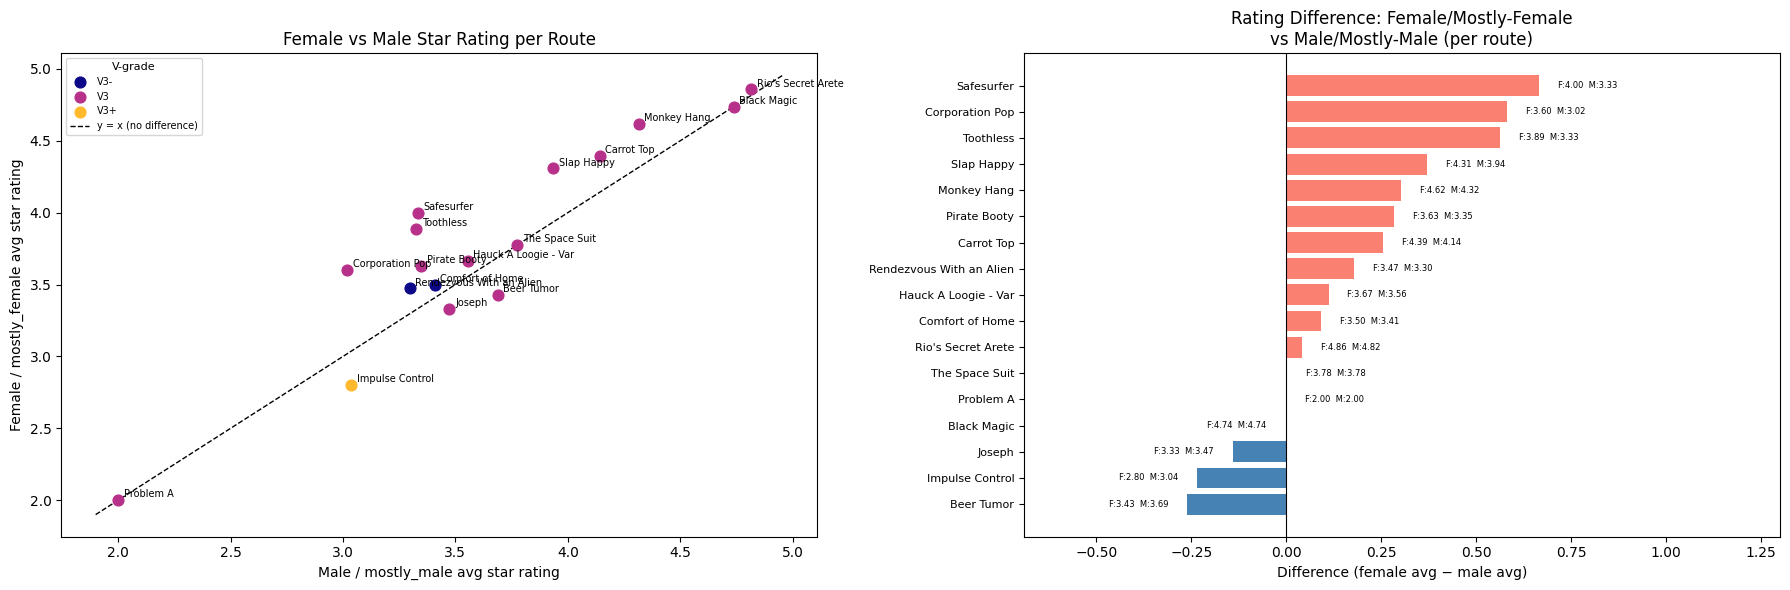

                          female_avg  male_avg  diff
Route                                               
Beer Tumor                      3.43      3.69 -0.26
Black Magic                     4.74      4.74 -0.00
Carrot Top                      4.39      4.14  0.25
Comfort of Home                 3.50      3.41  0.09
Corporation Pop                 3.60      3.02  0.58
Hauck A Loogie - Var            3.67      3.56  0.11
Impulse Control                 2.80      3.04 -0.24
Joseph                          3.33      3.47 -0.14
Monkey Hang                     4.62      4.32  0.30
Pirate Booty                    3.63      3.35  0.28
Problem A                       2.00      2.00  0.00
Rendezvous With an Alien        3.47      3.30  0.18
Rio's Secret Arete              4.86      4.82  0.04
Safesurfer                      4.00      3.33  0.67
Slap Happy                      4.31      3.94  0.37
The Space Suit                  3.78      3.78  0.00
Toothless                       3.89      3.33

In [36]:
plot_functions.plot_female_vs_male_rating(area_df = dfs['area_df_with_user_info'], min_counts = 5, included_grades = ['V3-'])

In [10]:
dfs['area_df_with_user_info']['comment'].dropna().drop_duplicates(keep = 'first')

7                                                         
69                     Scary top out of you don't trust it
80                     A bit weird, trickier than it looks
85                             Fun! Moved low left then up
89              ..top moves were a bit tough to figure out
                               ...                        
43929                      flash\n\nmy style\n\nreally fun
43944    ..missed the big move around the corner each t...
43947                                    Boo! Dont do it! 
43948                             Committing move up high!
43950                                                  FA?
Name: comment, Length: 4747, dtype: object

In [11]:
filtered_df = copy.deepcopy(dfs['area_df_with_user_info'])
filtered_df.dropna(subset = ['comment'], inplace = True)
filtered_df[filtered_df['comment'].str.contains('short | tall | reachy | sketchy | girl | boy | man | woman | female | male')][['Route', 'likely_gender', 'comment']].to_csv(f'data/{datetime.now().strftime('%Y%m%d_%H%M%S')}_{AREA_NAME}_comments.csv', index = False)

In [15]:
# add a plot where I see what routes have the highest rankings from women? And see which routes agree the most?

In [12]:
filtered_df.loc[filtered_df['comment'].str.contains('short | tall | reachy')][['comment', 'likely_gender']]

,comment,likely_gender
298,..struggled to figure out how to get to the po...,male
513,Cool climb! After looking up the short beta i...,male
531,"Attempt. Able to pinch lip, short of pocket.",female
1334,"Fun sloper problem, first go on the second da...",male
3599,sent in one short session,female
6969,"Wow, super short v10, shoulda known this woul...",mostly_male
12297,"Did harder short person variation, with crimp...",male
14065,fourth go. tall and scary,unknown
14207,"Tiny holds and slabby moves are the jam, so w...",male
15127,short lady beta,female


In [32]:
for _, row in filtered_df.loc[filtered_df['comment'].str.contains('short | tall | reachy')].iterrows():
    print(row["likely_gender"], row["comment"])

male  V1= old school Colorado 5.11a, on an exposed roof. 2nd try. First try was 1-2 years ago tho. Came back this time with Bob Horan&#39;s beta, to setup for the big move. Did the big move to the jug static. Committing both hands spooky, but w/ R. heel hook, stayed static. Finding the topout took some figuring out, & was reachy. ground up, no pads
male  Thing was hard. Maybe at 6’3” I just was too tall for the top movement to feel good. 
mostly_female  Pretty cool little easy short highball. Holds are worst at the topout but it's vertical/slabby there with big feat. Landing is reasonable.
male  4th try? No pad cause I’m dumb/poor. Used the crispy foot chip that aint long for this world and hucked to the positive nubbin, mellow spice locking the crack and pulling over. So fun. Agreed with the gb that it’s v2, esp if tall and/or use high Lheel 
female  I went from right to left and topped out about mid route. Even that short part of the climb was so good!! Need to come back to project t

In [ ]:
'''
2026-03-29 Next steps
- Figure out what other plots I want to make
        - what is the number of engagements (ticks/ratings/stars) each climb has? How many are repeats of the same user and how many are unique users?
                Create a function in plot_functions.py that will show me how many ticks, grade ratings, and star ratings each climb has. I think a bar plot would be best.
                I also want a function that plots the distribution (histogram) of how many ratings each climb got. 
        - look for comments that include keywords that might indicate gendered or height-dependent enjoyment.
- Clean up the code more
        - make sure functions all have explanations and are consistent logic
        - make it so that one function is called and that calls all of the other functions. 
- Compare comments from climbs males and females rated similarly vs climbs males and females rated differently. Basically, is there a correlation between height-related words showing up more frequently in comments concerning climbs that are gender preferred, or not. 
- Try again for the same areas using TheCrag instead - see if the gender ratio changes at all. 
- Figure out how/where to write up a report of my findings
- plot number of climbs per sub-area in designated grade ranges and star ratings 
        I want a function that will rank sub areas for which ones have the most climbs in a specified grade range and at least a minimum star rating that is supported by a specified number of ratings. Do this in plan mode. 
- Show some statistics about the number of engagements each user did
        histogram of engagements per user in an area. 
- the above can be used to filter for climbs that have at least some minimum number of engagements...
- How many users do I have age data for?
- Anything interesting I can look at over time? Maybe number of ticks added per year? Per month (as a way of seeing the peak climbing seasons)
- Filling in the user info takes the longest for sure...maybe I can focus on using the gender guesser to make up for it?
- see if there is a correlation between grade and male vs female interactions. 
- female vs male rankings - make a plot that highlights the climbs with the greatest difference between male and female rankings. 
- add line to user data function to sort unique users by the frequency of their interactions, so that the code tries to pull power user data first. 
- cite Santamaría L, Mihaljević H. 2018. Comparison and benchmark of name-to-gender inference services. PeerJ Computer Science 4:e156 https://doi.org/10.7717/peerj-cs.156 in regards to genderguesser
'''